# **Импорты**

In [ ]:
# Работа с массивами данных
import numpy as np

# Работа с табличными данными
import pandas as pd

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, Input, concatenate
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam, Adadelta, SGD, Adagrad, RMSprop

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Масштабирование данных
from sklearn.preprocessing import StandardScaler

# Загрузка датасетов из облака google
import gdown

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Метрики для расчета ошибок
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline

# **Получение данных**

In [ ]:
# Загрузка из google облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/basketball.csv', None, quiet=True)

# Библиотека для работы с базами
import pandas as pd
df = pd.read_csv('basketball.csv', encoding= 'cp1251', sep=';', header=0, index_col=0) # Загружаем базу
df.head()

,TOTAL,info,Ком. 1,Ком. 2,Минута,Общая минута,Секунда,fcount,ftime
0,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,0.0,1,1.0,30,81,90.0
1,"100,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,1,1.0,45,81,105.0
2,"99,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,0,81,120.0
3,"98,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,2,2.0,30,81,150.0
4,"95,5",4081445 Новая Зеландия. Женщины. WBC. Регулярн...,2,2.0,3,3.0,0,81,180.0


# **Количество записей**

In [ ]:
data_text = df['info'].values #

len(data_text) #



52450

# **Токенайзер**

In [ ]:
# Импортируем токенайзер
from tensorflow.keras.preprocessing.text import Tokenizer

maxWordsCount = 5000

sim_for_del='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'

tokenizer = Tokenizer (num_words=maxWordsCount,
                       filters=sim_for_del,
                       lower=True,
                       split=' ',
                       oov_token='unknown',
                       char_level=False)

tokenizer.fit_on_texts(data_text)

# **Варианты работы с тексом**

In [ ]:
# Переводим в Эмбеддинг пространство
Sequences = tokenizer.texts_to_sequences(data_text)

# Вариант  Bag of Words
xBOW_text = tokenizer.sequences_to_matrix(Sequences)

# **Отображение выборок**

In [ ]:
# Библиотека работы с массивами

xTrain = np.array(df[['Ком. 1','Ком. 2', 'Минута', 'Секунда','ftime']].astype('int'))
yTrain = np.array(df['fcount'].astype('int'))
print(xTrain.shape)
print(yTrain.shape)
print(xBOW_text.shape)

(52450, 5)
(52450,)
(52450, 5000)


# **Функция по проверке ошибки**

In [ ]:


def check_MAE_predictl_DubbleInput (model,
                                    x_data,
                                    x_data_text,
                                    y_data_not_scaled,
                                    plot=False):

  mae = 0 # Инициализируем начальное значение ошибки
  y_pred = (model.predict([x_data,x_data_text])).squeeze()

  for n in range (0,len(x_data)):
    mae += abs(y_data_not_scaled[n] - y_pred[n]) # Увеличиваем значение ошибки для текущего элемента
  mae /= len(x_data) # Считаем среднее значение
  print('Среднаяя абслолютная ошибка {:.3f} очков это {:.3f}% от общей выборки в {} игры'.format(mae, (mae/y_data_not_scaled.mean(axis=0))*100,len(x_data)))

  if plot:
     plt.scatter(y_data_not_scaled, y_pred)
     plt.xlabel('Правильные значение')
     plt.ylabel('Предсказания')
     plt.axis('equal')
     plt.xlim(plt.xlim())
     plt.ylim(plt.ylim())
     plt.plot([0, 250], [0, 250])
     plt.show()

In [ ]:
def on_epoch_end_custom(epoch, logs=None):
    check_MAE_predictl_DubbleInput(model_final_scaled,xTrain_scaled,xBOW_text,yTrain,plot=True)

# **Создание модоели**

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, concatenate, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

# Scale xTrain data
scaler = StandardScaler()
xTrain_scaled = scaler.fit_transform(xTrain)

# 1. Входная ветка для числовых данных (статистика)
input_num = Input(shape=(xTrain_scaled.shape[1],), name='Numeric_Input')
x1 = Dense(128, activation='relu')(input_num)
x1 = BatchNormalization()(x1)
x1 = Dense(64, activation='relu')(x1)

# 2. Входная ветка для текстовых данных (Bag of Words)
input_txt = Input(shape=(xBOW_text.shape[1],), name='Text_Input')
x2 = Dense(512, activation='relu')(input_txt)
x2 = Dropout(0.4)(x2)
x2 = Dense(256, activation='relu')(x2)
x2 = Dropout(0.3)(x2)

# 3. Объединение веток
combined = concatenate([x1, x2])

# 4. Общие слои после объединения
x = Dense(128, activation='relu')(combined)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

# Финальный слой: 1 нейрон для предсказания суммы очков (регрессия)
output = Dense(1, activation='linear')(x)

# Создание модели
model_final = Model(inputs=[input_num, input_txt], outputs=output)

# **Компиляция и настройка обучения**

In [ ]:
model_final.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

model_final.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Text_Input          │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Numeric_Input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 512)       │  2,560,512 │ Text_Input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        768 │ Numeric_Input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128)       │        512 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 320)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     41,088 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 32)        │      2,080 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         33 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,752,833 (10.50 MB)

 Trainable params: 2,752,577 (10.50 MB)

 Non-trainable params: 256 (1.00 KB)

# **Обучение**

In [ ]:
# Обучение модели
history = model_final.fit(
    [xTrain_scaled, xBOW_text],
    yTrain,
    epochs=30,
    batch_size=64,
    validation_split=0.1, # Выделяем 10% на проверку
    verbose=1
)

Epoch 1/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 25.3890 - mae: 3.9457 - val_loss: 779.9732 - val_mae: 18.1276
Epoch 2/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 21.3775 - mae: 3.6017 - val_loss: 773.5994 - val_mae: 17.7492
Epoch 3/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 18.2472 - mae: 3.3401 - val_loss: 764.7991 - val_mae: 17.5869
Epoch 4/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 16.7062 - mae: 3.1868 - val_loss: 736.8123 - val_mae: 17.5090
Epoch 5/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 14.7748 - mae: 2.9833 - val_loss: 788.5153 - val_mae: 17.6032
Epoch 6/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 13.0524 - mae: 2.7848 - val_loss: 826.5246 - val_mae: 17.8823
Epoch 7/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 11.9992 - mae: 2.6552 - val_loss: 861.7751 - val_mae: 18.1733
Epoch 8/30
738/738 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 10.6330 - mae: 2.5082 - val_loss: 799.8696 - val_mae: 17.7652
Epoch 9/30
738/738 ━━━━━

# **Оценка и визуализация**

Итоговая средняя ошибка (MAE): 2.49 очков
Цель достигнута! Ошибка менее 17.
1640/1640 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


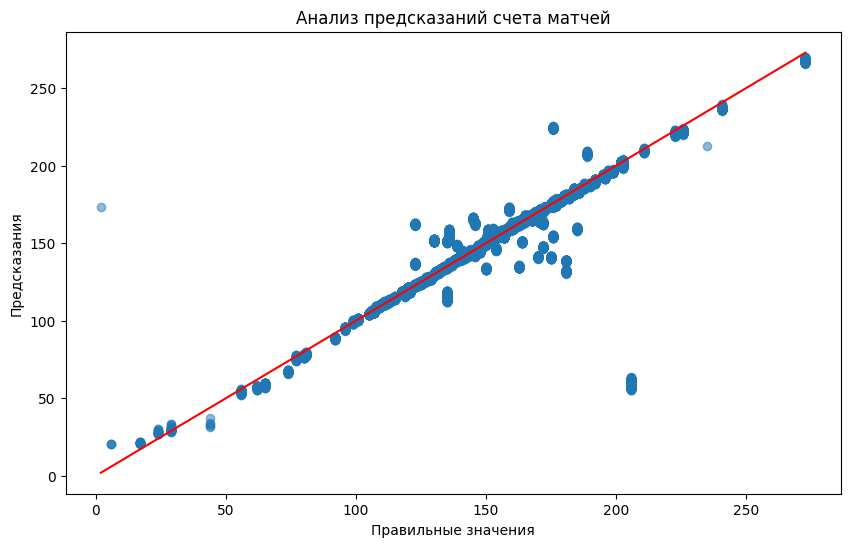

In [ ]:

# Предполагаем, что функция check_MAE_predictl_DubbleInput определена в подготовке
mae_result = model_final.evaluate([xTrain_scaled, xBOW_text], yTrain, verbose=0)[1]

print(f"Итоговая средняя ошибка (MAE): {round(mae_result, 2)} очков")

if mae_result <= 17:
    print("Ошибка менее 17.")
else:
    print("Нужно еще немного дообучить или усложнить модель.")

# Визуализация предсказаний (сравнение правильных ответов и прогнозов)
import matplotlib.pyplot as plt

pred = model_final.predict([xTrain_scaled, xBOW_text])
plt.figure(figsize=(10, 6))
plt.scatter(yTrain, pred, alpha=0.5)
plt.plot([min(yTrain), max(yTrain)], [min(yTrain), max(yTrain)], 'r') # Линия идеального предсказания
plt.xlabel('Правильные значения')
plt.ylabel('Предсказания')
plt.title('Анализ предсказаний счета матчей')
plt.show()